# Sentiment Analysis: Epstein File
**Analyzing Public Discourse on X (Twitter)**

---

## Background
The Epstein case became one of the most widely discussed legal controversies in recent years, attracting extensive global media coverage. The case raised serious concerns about **accountability, transparency, and institutional oversight**.

As new documents were released, public discussion on X (Twitter) surged. Analyzing this discourse provides insight into how media coverage shapes public sentiment.

---

## Problem Statement
1. How does the public respond to media coverage of the Epstein case on X?
2. What are the dominant themes and concerns that the Editorial Research team should highlight?

---

## Project Context
This project supports an **Editorial Research & Strategy team** seeking data-driven insights on public sentiment. By analyzing X posts, we identify dominant sentiments, frequently discussed topics, and key patterns — helping the editorial team produce more representative and relevant coverage.

---

## Analytical Workflow
| Step | Stage | Description |
|------|-------|-------------|
| 1 | **Data Collection** | Scrape posts from X using Epstein-related keywords |
| 2 | **Data Preprocessing** | Clean text: remove URLs, punctuation, stopwords |
| 3 | **Sentiment Labeling** | Label each post as positive, negative, or neutral |
| 4 | **EDA & Visualization** | Explore sentiment distribution, word frequency, n-grams |
| 5 | **Insights & Recommendations** | Derive editorial recommendations from findings |

---
# 1. Data Collection
Posts were scraped from X (Twitter) using **Tweet-Harvest**, a Node.js-based scraping tool. Keywords related to the Epstein case were used to collect relevant posts, which were then saved as `.csv` files and uploaded to Google Drive.

# Collect Data (Scrapt from Twitter)
The crawling process was done using Tweet-Harvest. Written by Helmi Satria on  March 30th 2024.



In [ ]:
!apt-get update
!apt-get install -y libatk1.0-0 libatk-bridge2.0-0 libcups2 libxkbcommon0 \
libxcomposite1 libxrandr2 libgbm1 libpangocairo-1.0-0 libpango-1.0-0 \
libgtk-3-0 libnss3 libasound2

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:5 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,929 kB]
Get:10 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.2 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/multiverse amd64 Packages [70.9 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,120 kB]
Get:1

In [ ]:
!npx playwright install chromium

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦Need to install the following packages:
playwright@1.58.2
Ok to proceed? (y) y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙╔═══════════════════════════════════════════════════════════════════════════════╗
║ WARNING: It looks like you are running 'npx playwright install' without first ║
║ installing your project's dependencies.                                       ║
║                                                                               ║
║ To avoid unexpected behavior, please install your dependencies first, and     ║
║ then run Playwright's install command:                                        ║
║                                                                               ║
║     npm install                                                               ║
║     npx playwright install                                                    ║
║                                                                               ║
║ If your project does not yet depend on Playwright, 

In [ ]:

# Install Node.js (because tweet-harvest built using Node.js)
!sudo apt-get update
!sudo apt-get install -y ca-certificates curl gnupg
!sudo mkdir -p /etc/apt/keyrings
!curl -fsSL https://deb.nodesource.com/gpgkey/nodesource-repo.gpg.key | sudo gpg --dearmor -o /etc/apt/keyrings/nodesource.gpg

!NODE_MAJOR=20 && echo "deb [signed-by=/etc/apt/keyrings/nodesource.gpg] https://deb.nodesource.com/node_$NODE_MAJOR.x nodistro main" | sudo tee /etc/apt/sources.list.d/nodesource.list

!sudo apt-get update
!sudo apt-get install nodejs -y

!node -v

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ca-certificates is already the newest version (20240203~22.04.1).
gnupg is already the newest 

In [ ]:
pip install sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 6.9 MB/s eta 0:00:00


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
from nltk.corpus import stopwords
import os
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from wordcloud import WordCloud
from google.oauth2 import service_account
import pandas_gbq
from datetime import timedelta
import pandas as pd
import time
from google.colab import files
from nltk.corpus import words
import shutil


In [ ]:
#@title Twitter Auth Token


twitter_auth_token = '2f367ad9b4fdd319073a06a028f776374c586106' # change this auth token

# Simpan credential di dictionary
userdata = {
    "twitter_auth_token": "2f367ad9b4fdd319073a06a028f776374c586106"
}

In [ ]:
# # calling twitter_auth_token from secrets
twitter_auth_token = userdata.get('twitter_auth_token')

# -------------------------------
# 2. Scrape Tweets Using tweet-harvest
# -------------------------------
# Specify the path to your CSV file
 # Crawl Data
since = pd.to_datetime('2026-01-01')
until = pd.to_datetime('2026-02-28')
end_date = pd.to_datetime('2026-01-31')
nomor = 1

while since <= end_date:
    # Format ke string agar dikenali kueri Twitter
    str_since = since.strftime('%Y-%m-%d')
    str_until = until.strftime('%Y-%m-%d')

    filename = f'Epstain_{nomor}.csv'
    search_keyword = f'epstain lang:in since:{str_since} until:{str_until} -filter:links'

    limit = 300
    print(f"--- Batch {nomor} ---")
    print(f"Searching: {search_keyword}")

    # Eksekusi tweet-harvest
    !npx -y tweet-harvest@2.6.1 -o "{filename}" -s "{search_keyword}" --tab "LATEST" -l {limit} --token {twitter_auth_token}

    since = since + timedelta(days=1)
    until = until + timedelta(days=1)
    nomor += 1

    if since <= end_date:
        print(f"Selesai batch {nomor-1}, nunggu 20 detik biar aman...")
        time.sleep(20)

--- Batch 1 ---
Searching: epstain lang:in since:2026-01-01 until:2026-02-02 -filter:links
⠙⠹⠸⠼⠴⠦⠧Tweet Harvest [v2.6.1]

Research by Helmi Satria
Use it for Educational Purposes only!

This script uses Chromium Browser to crawl data from Twitter with your Twitter auth token.
Please enter your Twitter auth token when prompted.

Note: Keep your access token secret! Don't share it with anyone else.
Note: This script only runs on your local device.


Opening twitter search page...


-- Scrolling... (1) (2) (3)
Filling in keywords: epstain lang:in since:2026-01-01 until:2026-02-02 -filter:links

 (4) (5)[v2.6.1] Error: page.waitForResponse: Target page, context or browser has been closed
Keywords: epstain lang:in since:2026-01-01 until:2026-02-02 -filter:links
Twitter Harvest v 2.6.1
node:internal/process/promises:391
    triggerUncaughtException(err, true /* fromPromise */);
    ^

page.screenshot: Target page, context or browser has been closed
    at crawl (/root/.npm/_npx/d28e8c2154917

KeyboardInterrupt: 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Define the directory to be uploaded
directory_to_upload = '/content/tweets-data/'

# Define the destination folder in Google Drive
gdrive_destination_folder = '/content/drive/MyDrive/purwadhika/Porto_Sentimen_JefreyAbstein/Epstein_Raw'
os.makedirs(gdrive_destination_folder, exist_ok=True)

print(f"Uploading files from '{directory_to_upload}' to Google Drive: {gdrive_destination_folder}...")

# Iterate through files in the source directory and move them to Google Drive
for filename in os.listdir(directory_to_upload):
    source_path = os.path.join(directory_to_upload, filename)
    destination_path = os.path.join(gdrive_destination_folder, filename)
    if os.path.isfile(source_path): # Only move files, not subdirectories
        shutil.move(source_path, destination_path)
        print(f"Moved '{filename}' to '{gdrive_destination_folder}'")

print("All files successfully moved to Google Drive.")

Uploading files from '/content/tweets-data/' to Google Drive: /content/drive/MyDrive/purwadhika/Porto_Sentimen_JefreyAbstein/Epstein_Raw...
Moved 'Epstain_2.csv' to '/content/drive/MyDrive/purwadhika/Porto_Sentimen_JefreyAbstein/Epstein_Raw'
All files successfully moved to Google Drive.


In [ ]:
#Concat data from drive
# Define the folder path where the CSV files are located
folder_path = '/content/drive/MyDrive/purwadhika/Porto_Sentimen_JefreyAbstein/Epstein_Raw'
output_folder = '/content/drive/MyDrive/purwadhika/Porto_Sentimen_JefreyAbstein'

# List to store individual DataFrames
dfs = []

# Iterate through each file in the folder
for filename in os.listdir(folder_path):
    if filename.startswith('Epstein_') and filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        try:
            df = pd.read_csv(file_path)
            dfs.append(df)
            print(f"Successfully read: {filename}")
        except Exception as e:
            print(f"Error reading {filename}: {e}")

# Concatenate all DataFrames if any were found
if dfs:
    concatenated_df = pd.concat(dfs, ignore_index=True)

    # Define the output path for the combined CSV file
    output_filename = 'Epstein_Files_Concatenated.csv'
    output_path = os.path.join(output_folder, output_filename)

    # Save the concatenated DataFrame to a new CSV file
    concatenated_df.to_csv(output_path, index=False)
    print(f"\nAll files concatenated and saved to: {output_path}")
    print(f"Total rows in concatenated file: {len(concatenated_df)}")
else:
    print("No matching CSV files found to concatenate.")

Successfully read: Epstein_Feb_2026.csv
Successfully read: Epstein_Des_2026.csv
Successfully read: Epstein_Nov_2026.csv
Successfully read: Epstein_Jan_2026.csv

All files concatenated and saved to: /content/drive/MyDrive/purwadhika/Porto_Sentimen_JefreyAbstein/Epstein_Files_Concatenated.csv
Total rows in concatenated file: 3261


In [ ]:
#drop duplicate data
df = pd.read_csv('/content/drive/MyDrive/purwadhika/Porto_Sentimen_JefreyAbstein/Epstein_Files_Concatenated.csv')
df.drop_duplicates(inplace=True)
df

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,2030857967696785851,2026-03-10 23:59:06+00:00,0,@sploder6 @DavidNachman3 @59SouthLee @BackupJe...,2031520251653865520,NaN,sploder6,en,NaN,0,1,0,https://x.com/undefined/status/203152025165386...,1720665183188922368,NaN
1,2031479426836316296,2026-03-10 23:58:47+00:00,0,@Israel2252 Not all Jews but all Zionists are ...,2031520170703798651,NaN,Israel2252,en,NaN,0,0,0,https://x.com/undefined/status/203152017070379...,2845845628,NaN
2,2031217139353309554,2026-03-10 23:56:45+00:00,0,@Parodyjeffx # I @realDonaldTrump wants the Am...,2031519658818548209,NaN,Parodyjeffx,en,NaN,0,0,0,https://x.com/undefined/status/203151965881854...,229414949,NaN
3,2031145454843445718,2026-03-10 23:54:50+00:00,0,@DickSinnya @NicholasGuyatt Typical Yankee Doo...,2031519180059754856,NaN,DickSinnya,en,NaN,0,1,0,https://x.com/undefined/status/203151918005975...,1677810281249144832,NaN
4,2031505052108566870,2026-03-10 23:54:43+00:00,2,@jacksonhinklle My heart is broken. America ki...,2031519150506438922,NaN,jacksonhinklle,en,NaN,0,0,0,https://x.com/undefined/status/203151915050643...,111829570,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3252,2015793441846763878,2026-01-26 14:26:22+00:00,0,RELEASE THE EPSTEIN FILES Don't stop talking ...,2015793441846763878,NaN,NaN,en,NaN,0,0,0,https://x.com/undefined/status/201579344184676...,1360191822,NaN
3253,2015779345852158395,2026-01-26 13:30:22+00:00,0,When the left was trying to ruin Trump bankrup...,2015779345852158395,NaN,NaN,en,NaN,0,0,0,https://x.com/undefined/status/201577934585215...,1604337455280291842,NaN
3254,2015776762316128560,2026-01-26 13:20:06+00:00,1,Where is the corruption of federal law being b...,2015776762316128560,NaN,NaN,en,NaN,0,1,0,https://x.com/undefined/status/201577676231612...,1587789960920399873,NaN
3255,2015759737082585208,2026-01-26 12:12:26+00:00,0,If the evidence in the EPSTEIN FILES and Jack ...,2015759737082585208,NaN,NaN,en,NaN,0,0,0,https://x.com/undefined/status/201575973708258...,56852049,NaN


---
# 2. Data Storage
Collected data is exported to **Google BigQuery** for scalable storage and querying, then re-loaded for analysis.

# Export Data to Google Big Query

In [ ]:
# BigQuery configurations
project_id = 'porto-489909'
dataset_id = 'porto_sentimen'
table_name = 'epstein_case'
key_path = 'porto-489909-d1e56881ea6b.json'  # key path of json file

# Set up credentials
scopes = ["https://www.googleapis.com/auth/bigquery"]
credentials = service_account.Credentials.from_service_account_file(
    'porto-489909-d1e56881ea6b.json' ,
    scopes=["https://www.googleapis.com/auth/bigquery"]
)

# Upload the data to BigQuery
pandas_gbq.to_gbq(
    df,
    f'{dataset_id}.{table_name}',
    project_id=project_id,
    if_exists='replace',
    credentials=credentials
)

100%|██████████| 1/1 [00:00<00:00, 4583.94it/s]


# Read Data from Google Big Query

In [ ]:
# BigQuery configurations
project_id = 'porto-489909'
dataset_id = 'porto_sentimen'
table_name = 'epstein_case'


sql_query = f"""
SELECT *
FROM `{project_id}.{dataset_id}.{table_name}`
"""

# Retrieve data from BigQuery into a DataFrame
df = pandas_gbq.read_gbq(
    sql_query,
    project_id=project_id,
    credentials=credentials
)
df


Downloading: 100%|██████████|


,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,2031509643273396393,2026-03-10 23:21:45+00:00,0,2 men are charged with using a weapon of mass...,2031510852881264963,None,V_News8,en,NaN,0,0,0,https://x.com/undefined/status/203151085288126...,1710135965795188737,NaN
1,2032045484852830630,Thu Mar 12 10:46:11 +0000 2026,0,ATTORNEY GENERAL PAM BONDI HAS MOVED TO A MIL...,2032045484852830630,https://pbs.twimg.com/media/HDNGmcRWAAAOYx8.jpg,None,en,NaN,0,0,0,https://x.com/undefined/status/203204548485283...,48115695,NaN
2,1985134759811358959,Sun Nov 02 23:59:43 +0000 2025,0,Breaking maga News holy shit if it comes out ...,1985134759811358959,None,None,en,NaN,0,0,0,https://x.com/undefined/status/198513475981135...,1237140836426678273,NaN
3,2032045419107356723,Thu Mar 12 10:45:56 +0000 2026,0,CRAZY: 🇺🇸🇮🇱 An email in the Epstein Files sug...,2032045419107356723,https://pbs.twimg.com/media/HDNGh6pbQAEBdLL.jpg,None,en,NaN,0,0,0,https://x.com/undefined/status/203204541910735...,2028755439366946816,NaN
4,2031492795588825290,2026-03-10 22:10:00+00:00,0,Channel 12 (Hebrew) The Jews are preparing fo...,2031492795588825290,https://pbs.twimg.com/media/HDFP7TRXcAAjqeE.jpg,None,en,NaN,0,0,0,https://x.com/undefined/status/203149279558882...,102819678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2257,2003612982161371186,Tue Dec 23 23:45:34 +0000 2025,3613,There has been lots of sensationalism and even...,2003612982161371186,None,None,en,NaN,195,2673,964,https://x.com/undefined/status/200361298216137...,1910742306820378624,NaN
2258,2010374151198974178,2026-01-11 15:32:03+00:00,5965,Pam Bondi is burying the Epstein files for Tru...,2010374151198974178,None,None,en,NaN,17,86,1579,https://x.com/undefined/status/201037415119897...,15691324,NaN
2259,1992527741628129508,Sun Nov 23 09:36:47 +0000 2025,10419,Trump is reportedly concerned that his tariffs...,1992527741628129508,None,None,en,NaN,154,978,1748,https://x.com/undefined/status/199252774162812...,1186076316786814977,NaN
2260,1989463748512477324,Fri Nov 14 22:41:34 +0000 2025,45090,Pam Bondi just reopened an Epstein investigati...,1989463748512477324,None,None,en,NaN,205,481,8581,https://x.com/undefined/status/198946374851247...,2898790691,NaN


---
# 3. Data Cleaning & Preprocessing
Raw tweet text is cleaned through the following steps:

| Step | Process |
|------|---------|
| Text Cleaning | Remove mentions, hashtags, URLs, numbers, punctuation |
| Case Folding | Convert all text to lowercase |
| Tokenization | Split text into individual words |
| Slang Normalization | Replace informal words with standard forms |
| Stopword Filtering | Remove stopwords, keep meaningful keywords |
| Lemmatization | Reduce words to their base dictionary form |
| Text Reconstruction | Rejoin processed tokens into clean text |

# Data Cleaning & Preprocessing

In [ ]:
# Set Up
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('words')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


True

In [ ]:
from nltk.stem import WordNetLemmatizer

# Inisialisasi
lemmatizer = WordNetLemmatizer()

custom_stopwords = {
    'file', 'files', 'release', 'released', 'releases', 'releasing',
    'epstein', 'trump', 'case', 'jeffrey', 'jeffery', 'would', 'said',
    'trumpepstein', 'pam', 'bondi', 'distract', 'distraction', 'mention',
    'transparency', 'act', 'get', 'one', 'also', 'even', 'still', 'amp',
    'jack', 'smith',
}


listStopwords = set(stopwords.words('english')).union(custom_stopwords)

def removeSlangWords(text):
    slang_words = {
        'idk': "i don't know",
        'fomo': 'fear of missing out',
        'omg': 'oh my god',
        'ikr': 'i know right',
    }
    words = text.split()
    words = [slang_words[word] if word in slang_words else word for word in words]
    return ' '.join(words)

def preprocess(text):
    text = re.sub(r'&amp;', '', text)
    text = re.sub(r'@[A-Za-z0-9]+', '', text)
    text = re.sub(r'#[A-Za-z0-9]+', '', text)
    text = re.sub(r'RT[\s]', '', text)
    text = re.sub(r"http\S+", '', text)
    text = re.sub(r'[0-9]+', '', text)
    text = text.replace('\n', ' ')
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip()
    text = text.lower()
    text = removeSlangWords(text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in listStopwords]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    tokens = [t for t in tokens if len(t) > 2]
    return tokens

df['text_clean'] = df['full_text'].apply(preprocess)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
df

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username,text_clean,polarity_score,polarity,character_length,word_length
0,2031509643273396393,2026-03-10 23:21:45+00:00,0,2 men are charged with using a weapon of mass destruction after IEDs are tossed near NYC mayor s home Alexander brothers are convicted of sex trafficking in case that shocked real estate world New Mexico authorities search Zorro Ranch formerly owned by Epstein,2031510852881264963,None,V_News8,en,NaN,0,0,0,https://x.com/undefined/status/2031510852881264963,1710135965795188737,NaN,"[men, charged, using, weapon, mass, destruction, ied, tossed, near, nyc, mayor, home, alexander, brother, convicted, sex, trafficking, shocked, real, estate, world, new, mexico, authority, search, zorro, ranch, formerly, owned]",-0.8271,negative,261,28
1,2032045484852830630,Thu Mar 12 10:46:11 +0000 2026,0,ATTORNEY GENERAL PAM BONDI HAS MOVED TO A MILITARY BASE IN THE CAPITAL AREA FOR SAFETY! After receiving DEADLY THREATS from DRUG CARTELS and CRITICS over her handling of the JEFFREY EPSTEIN FILES she fled her WASHINGTON D.C. apartment in a LAST-MINUTE ESCAPE. This is NOT a https://t.co/qiVi4680DH,2032045484852830630,https://pbs.twimg.com/media/HDNGmcRWAAAOYx8.jpg,None,en,NaN,0,0,0,https://x.com/undefined/status/2032045484852830630,48115695,NaN,"[attorney, general, moved, military, base, capital, area, safety, receiving, deadly, threat, drug, cartel, critic, handling, fled, washington, apartment, lastminute, escape]",-0.2500,negative,298,20
2,1985134759811358959,Sun Nov 02 23:59:43 +0000 2025,0,Breaking maga News holy shit if it comes out that former Presidents new what was in the Epstein files regarding trump wire transfers evidence of a cover up to protect a pedophile they should be held accountable,1985134759811358959,None,None,en,NaN,0,0,0,https://x.com/undefined/status/1985134759811358959,1237140836426678273,NaN,"[breaking, maga, news, holy, shit, come, former, president, new, regarding, wire, transfer, evidence, cover, protect, pedophile, held, accountable]",-0.2500,negative,211,18
3,2032045419107356723,Thu Mar 12 10:45:56 +0000 2026,0,CRAZY: 🇺🇸🇮🇱 An email in the Epstein Files suggests ISIS and Al-Qaeda are likely American and Israeli assets. #Iran #IranWar #IranIsraelWar https://t.co/hqPD9NzjmE,2032045419107356723,https://pbs.twimg.com/media/HDNGh6pbQAEBdLL.jpg,None,en,NaN,0,0,0,https://x.com/undefined/status/2032045419107356723,2028755439366946816,NaN,"[crazy, 🇺🇸🇮🇱, email, suggests, isi, alqaeda, likely, american, israeli, asset]",0.0258,neutral,163,10
4,2031492795588825290,2026-03-10 22:10:00+00:00,0,Channel 12 (Hebrew) The Jews are preparing for a scenario in which Trump suddenly ends the war. Therefore the Jews army will intensify its attacks on Iran. In anticipation of the possibility that Trump will suddenly end the war. The full Epstein file will be released. https://t.co/MyVOzYwHNL,2031492795588825290,https://pbs.twimg.com/media/HDFP7TRXcAAjqeE.jpg,None,en,NaN,0,0,0,https://x.com/undefined/status/2031492795588825290,102819678,NaN,"[channel, hebrew, jew, preparing, scenario, suddenly, end, war, therefore, jew, army, intensify, attack, iran, anticipation, possibility, suddenly, end, war, full]",-0.8885,negative,293,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2257,2003612982161371186,Tue Dec 23 23:45:34 +0000 2025,3613,There has been lots of sensationalism and even outright lies these past few days about the Epstein Files. But let s separate fact from fiction. Document production is just that. We produce documents and sometimes this can result in releasing fake or false documents because,2003612982161371186,None,None,en,NaN,195,2673,964,https://x.com/undefined/status/2003612982161371186,1910742306820378624,NaN,"[lot, sensationalism, outright, lie, past, day, let, separate, fact, fiction, document, productio

In [ ]:
#load data clean
# BigQuery configurations
project_id = 'porto-489909'
dataset_id = 'porto_sentimen'
table_name = 'epstein_case_clean'
key_path = 'porto-489909-d1e56881ea6b.json'  # key path of json file

# Set up credentials
scopes = ["https://www.googleapis.com/auth/bigquery"]
credentials = service_account.Credentials.from_service_account_file(
    'porto-489909-d1e56881ea6b.json' ,
    scopes=["https://www.googleapis.com/auth/bigquery"]
)

# Upload the data to BigQuery
pandas_gbq.to_gbq(
    df[['text_clean']],
    f'{dataset_id}.{table_name}',
    project_id=project_id,
    if_exists='replace',
    credentials=credentials
)

100%|██████████| 1/1 [00:00<00:00, 8456.26it/s]


---
# 4. Sentiment Analysis
Sentiment polarity is assigned to each post using **VADER (Valence Aware Dictionary and sEntiment Reasoner)**, classifying posts as `positive`, `negative`, or `neutral`.

# Sentiment Polarity  with Indonesian Sentiment Lexicon

In [ ]:
pip install vaderSentiment

In [ ]:
#Apply sentimen analysis
import vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def sentiment_label(tokens):
    # Join the list of tokens into a single string
    text_string = ' '.join(tokens)
    # Use 'compound' instead of 'score'
    score = analyzer.polarity_scores(text_string)['compound']

    if score > 0.10:
        polarity_string = "positive"
    elif score < -0.10:
        polarity_string = "negative"
    else:
        polarity_string = "neutral"
    return score, polarity_string

In [ ]:
results = df['text_clean'].apply(sentiment_label)
results = list(zip(*results))
df['polarity_score'] = results[0]
df['polarity'] = results[1]
print(df['polarity'].value_counts())

polarity
negative    1121
positive     578
neutral      563
Name: count, dtype: int64


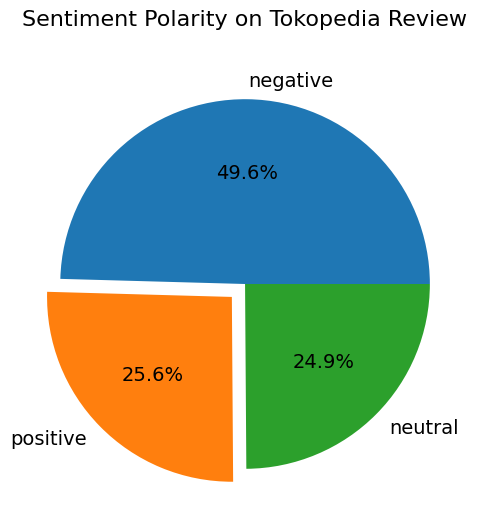

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
counts = df['polarity'].value_counts()
labels = list(counts.index)
sizes = list(counts.values)
explode = (0, 0.1, 0)
ax.pie(x=sizes, labels=labels, autopct='%1.1f%%', explode=explode, textprops={'fontsize': 14})
ax.set_title('Sentiment Polarity on Tokopedia Review', fontsize=16, pad=20)

total = sum(sizes)
plt.savefig('pie_plot.png')
plt.show()


## 4.1 Tweet Samples by Sentiment
Sample tweets from each sentiment class to validate labeling quality.

## Positive Tweet Example

In [ ]:
pd.set_option('display.max_colwidth', 3000)
positive_tweets = df[df['polarity'] == 'positive']
positive_tweets = positive_tweets[['full_text', 'polarity_score', 'polarity']].sort_values(by = 'polarity_score', ascending=False).reset_index(drop = True)
positive_tweets.index += 1
positive_tweets.to_csv('positive_tweets.csv', index=False)
positive_tweets[0:30]

,full_text,polarity_score,polarity
1,@RepThomasMassie Thomas as an Independent voter I would like to thank you for acting in a bipartisan manner and seeking the truth. I appreciate your service and keep up the fight great job! Keep pushing for the release of the Epstein files thank you. We need the truth not cover ups.,0.9360,positive
2,Wow news flash in the #Epstein case. A rich guy hanging around other rich men. Epstein was a power player of course he had pictures with rich and famous. Where is the dirt the evidence that these people had sex with underage women where is the proof of anything. Put up or shut up,0.9217,positive
3,@YouKnoImHim Nick's right Trump (and by extension MAGA) loved Massie until Massie endorsed the better champion of conservatism in 2024; Ron DeSantis. Pushing for Trump's campaign promise of declassifying the Epstein files infuriated Trump for some reason. Who is your favorite Rep in DC?,0.9186,positive
4,The left wants @AGPamBondi arrested because of the Epstein files. The right will oust her because she s about to butcher the Mangione case with clear conflicts of interest and evidence mishandling lmao A win is a win.,0.9186,positive
5,@bayoublondepat @ShadowofEzra @RepJamesComer @idontexistTore Yup and fascinating find was their trust sounds like pizzagate comet trust in the epstein files,0.9118,positive
6,@SamreenNaz99 Donald Trump has always been my friend but ever since Epstein files came out there's a bit of gap in our friendship now so yes you can say I am talking about him. Yes he doesn't know his next move he is not even having enough sleep now Khamenei has casted a spell on him.,0.8885,positive
7,Many cryingwhistleblowers coming out in the Epstein case often presenting pictorial evidence of them smiling partying with friends in exotic clubs and locales. All clearly 18+. Q: how much did they get payed (salary) while being kidnapped or trafficked? Or was it hourly.,0.8885,positive
8,@tracegallagher What is a successful mission? The mission was to distract from the Epstein files so I hope the mission is NOT successful and the files are released and Trump removed from office.,0.8885,positive
9,@SamreenNaz99 Donald Trump has always been my friend but ever since Epstein files came out there's a bit of gap in our friendship now so yes you can say I am talking about him. Yes he doesn't know his next move he is not even having enough sleep now Khamenei has casted a spell on him.,0.8885,positive
10,The National Mall has a giant replica of Trumps birthday card to Epstein. Only 6% of Americans are satisfied with how the EPSTEIN FILES are being handled. Two EPSTEIN survivors have filed documents to have a Special Master appointed to force the files to be released. So brave!,0.8860,positive


## Neutral Tweet Example

In [ ]:
pd.set_option('display.max_colwidth', 3000)
negative_tweets = df[df['polarity'] == 'neutral']
negative_tweets = negative_tweets[['full_text', 'polarity_score', 'polarity']].sort_values(by = 'polarity_score', ascending=True).reset_index(drop = True)
negative_tweets.index += 1
negative_tweets[0:30]

,full_text,polarity_score,polarity
1,If Epstein Files are a hoax why did @SpeakerJohnson fight the bill @FBI spend $1 mil trying to redact @AGPamBondi give out binders @GOPoversight subpoena estate @TheJusticeDept open investigation ⁉️@realDonaldTrump sign Epstein bill Justice is coming.,-0.0772,neutral
2,Trump signed the Epstein Files Transparency Act into law last month instructing the Justice Department to disclose all documents it possessed regarding Epstein. It set a deadline of December 19. Democrats and there TDS and chaos they cause. What is your agenda for 28? NOTHING!,-0.0772,neutral
3,Who has the balls to let lose the Epstein files and Jack Smiths security documents judge cannon is holding back FROM THE AMERICAN PEOPLE,-0.0772,neutral
4,We must investigate Bondi's ties to Pfizer as she halted their investigation after receiving $200 000 from them. She falsely claimed to have the Epstein files ON HER DESK and didn't act with the J6 committee compromising crucial evidence. This raises serious concerns!,-0.0772,neutral
5,Sorry he s in the Epstein files and hasn t been with the company for almost 15 years. His opinion is moot,-0.0772,neutral
6,See who's connected in the Epstein files exposed through 2 496 021+ documents. https://t.co/WjpXArm1zj,-0.0772,neutral
7,@khamenei_ir The Epstein case permanently blurred the lines between politics wealth and crime.,-0.0772,neutral
8,Feeling ready to read Epstein files. Pam Bondi is going to prison for withholding these documents.,-0.0772,neutral
9,@tuckyoglockk @njzhoney @biggestgllit @dollsumin Hybe bought tag PR to harass new jeans and mhj tag PR a firm used by Baldoni to defame Blake Lively a firm whose founder Melissa Nathan is mentioned on the Epstein files because she worked to rehabilitate his image Read her name source: DOJ https://t.co/5QvfxgLNO9,-0.0772,neutral
10,@wendyp4545 My best guess israel had to stage to make false flags attacks and blame Iran for it because of the epstein files and release of jfk files I now assume Israel is behind everything,-0.0772,neutral


## Negative Tweet Example

In [ ]:
pd.set_option('display.max_colwidth', 3000)
negative_tweets = df[df['polarity'] == 'negative']
negative_tweets = negative_tweets[['full_text', 'polarity_score', 'polarity']].sort_values(by = 'polarity_score', ascending=True).reset_index(drop = True)
negative_tweets.index += 1
negative_tweets.to_csv('negative_tweets.csv', index=False)
negative_tweets[0:30]

,full_text,polarity_score,polarity
1,@RepThomasMassie Pedophiles rapist and kleptocrats belong behind bars period. RELEASE ALL THE EPSTEIN FILES NOW. Pedophiles and rapist must get the death penalty. Those protecting the pedophiles and rapist must get the death penalty too. RELEASE ALL THE CONGRESS FILES TOO NOW.,-0.9842,negative
2,When the Epstein files resurface Donald Trump floods the zone. National Guard theatrics Iran war threats Venezuela aggression and Somalia fraud panic are not governance they are distractions. Soldiers bombs and enemies always beat documents and accountability. Fear is,-0.9819,negative
3,Millennials after living through the dotcom crash 9/11 war in Afghanistan the 2008 financial crisis COVID war in Ukraine Epstein files AI taking their jobs war in Iran and now the worst oil crisis ever https://t.co/kqQnZr436q,-0.9812,negative
4,Millennials after living through the dotcom crash 9/11 war in Afghanistan the 2008 financial crisis COVID war in Ukraine Epstein files AI taking their jobs war in Iran and now the worst oil crisis ever https://t.co/kqQnZr436q,-0.9812,negative
5,Millennials after living through the dotcom crash 9/11 war in Afghanistan the 2008 financial crisis COVID war in Ukraine Epstein files AI taking their jobs war in Iran and now the worst oil crisis ever https://t.co/kqQnZr436q,-0.9812,negative
6,@JesseBWatters Trump will go down in history but not for any greatness. He will be remembered for the chaos corruption illegality the lies the sexual assaults the incompetent administration no health plan the hiding of the Epstein files the illegal war &amp; tariffs &amp; domestic killings.,-0.9769,negative
7,Epstein files no arrests Jan 6 no arrests Auto pen no arrests Congress slush fund no arrests Shifty Schiff no arrests Seditious six no arrests Big Tish no arrests Stolen elections no arrests Obama no arrests What is it going to take for people to be held accountable?,-0.9735,negative
8,They call it OPERATION EPIC FURY because they're FURIOUS that Trump has been exposed as a CHILD RAPIST in the Epstein Files and Elon Musk has been found to have committed ELECTION FRAUD in 2024! They'll BOMB THE ENTIRE WORLD to distract from their CRIMES! They know it's OVER!,-0.9719,negative
9,@elonmusk Let's get down to the big crimes &amp; the biggest criminals hidden in the Epstein files Dancing as round the facts that these of crimes happens in America daily... YET refusing to unveil the most FUCKED UP diabolical most evil acts on WHITE children's hidden in the Epstein https://t.co/JhWI2bSD5g,-0.9716,negative
10,@PressSec SO MANY LIES!! The trump admin is constantly lying while concealing American casualties. Lying about dead Iranian children. Blocking terror warnings to law enforcement. Sealing the Epstein files. This is their pattern. https://t.co/RbeAs2tBS3,-0.9716,negative


## 4.2 Sentiment Score Distribution
Boxplot showing the spread of polarity scores across sentiment classes.

## Sentiment Score Distribution

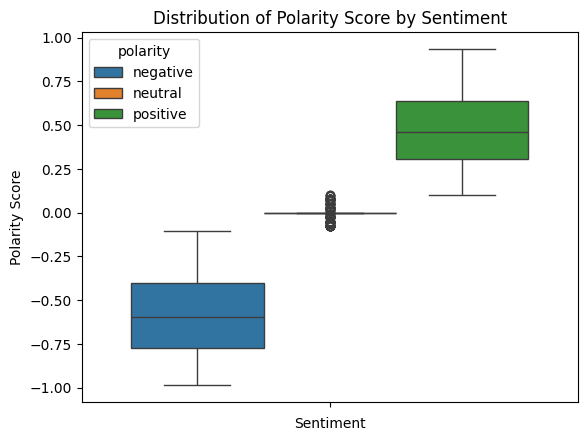

In [ ]:
sns.boxplot(hue='polarity', y='polarity_score', data=df)
plt.xlabel('Sentiment')
plt.ylabel('Polarity Score')
plt.title('Distribution of Polarity Score by Sentiment')
plt.savefig('boxplot_sentiment_polarity_distribution.png')
plt.show()

---
# 5. Exploratory Data Analysis (EDA)
Exploring word frequency, text length, and temporal patterns in the dataset.

## 5.1 Top 10 Most Common Words
The most frequent words across all posts, reflecting key themes in the discussion.

## Top 10 Common Words

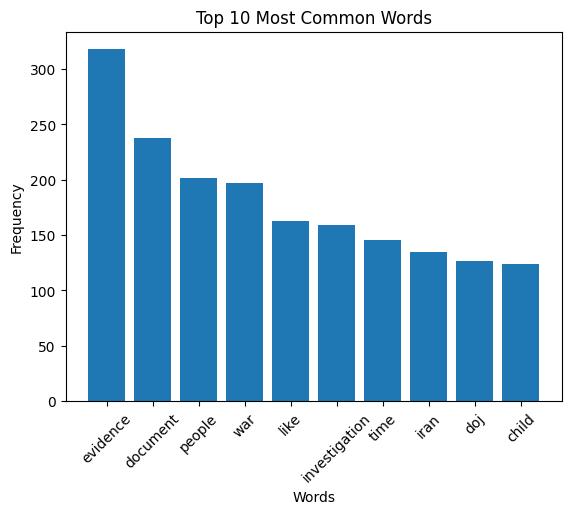


Top 10 Most Common Words:
evidence : 318
document : 238
people : 202
war : 197
like : 163
investigation : 159
time : 146
iran : 135
doj : 127
child : 124


In [ ]:
from collections import Counter

all_words = ' '.join(' '.join(words) for words in df['text_clean'])
word_counts = Counter(all_words.split())

top_words = word_counts.most_common(10)
labels, values = zip(*top_words)

plt.bar(labels, values)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 10 Most Common Words')
plt.xticks(rotation=45)
plt.savefig('barPlot_top_10_words.png')
plt.show()

print("\nTop 10 Most Common Words:")
for word, count in top_words:
    print(f"{word} : {count}")

## 5.2 Text Length Distribution
Distribution of character and word counts — helps understand tweet verbosity.

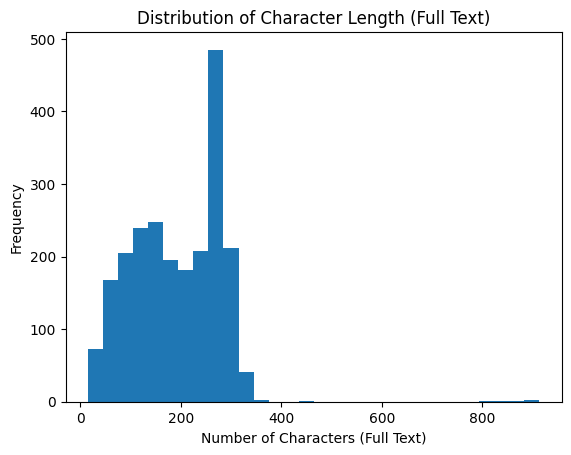

In [ ]:
character_lengths_full_text = df['full_text'].apply(len)

plt.hist(character_lengths_full_text, bins=30)
plt.xlabel('Number of Characters (Full Text)')
plt.ylabel('Frequency')
plt.title('Distribution of Character Length (Full Text)')
plt.savefig('character_length_distribution.png')
plt.show()

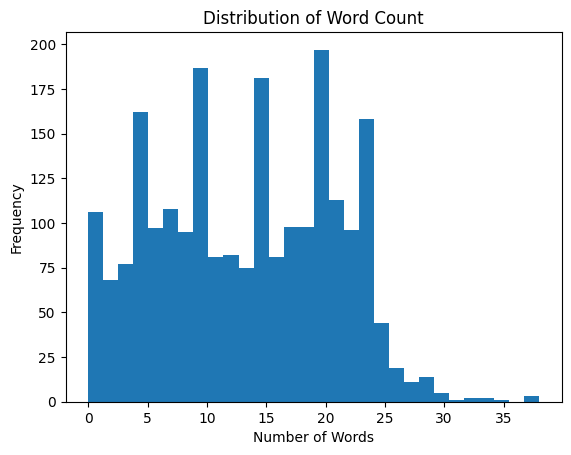

In [ ]:
tweet_lengths = df['text_clean'].apply(lambda x: len(x)) # Calculate word count

plt.hist(tweet_lengths, bins=30)
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.title('Distribution of Word Count')
plt.savefig('word_count_distribution.png')
plt.show()

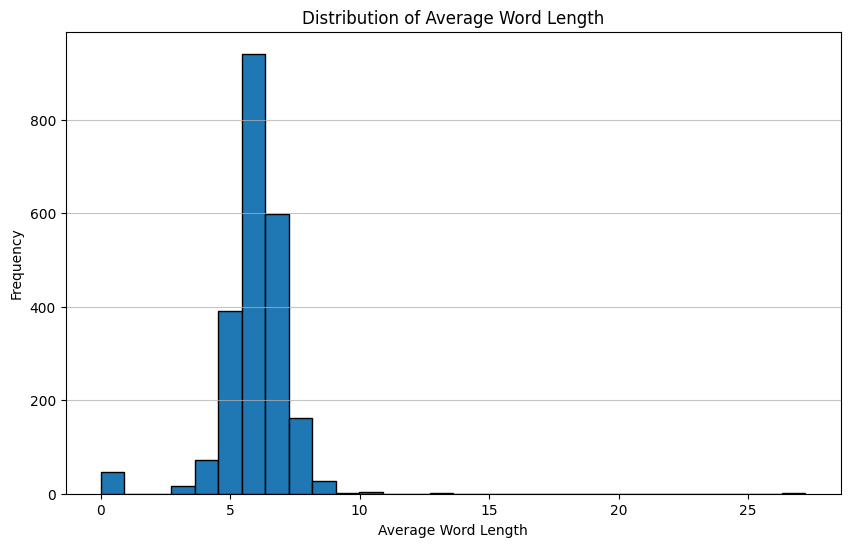

In [ ]:
# Calculate average word length for each tweet
def calculate_average_word_length(word_list):
    if not word_list:
        return 0
    total_length = sum(len(word) for word in word_list)
    return total_length / len(word_list)

df['average_word_length'] = df['text_clean'].apply(calculate_average_word_length)

# Plotting the distribution of average word length
plt.figure(figsize=(10, 6))
plt.hist(df['average_word_length'], bins=30, edgecolor='black')
plt.xlabel('Average Word Length')
plt.ylabel('Frequency')
plt.title('Distribution of Average Word Length')
plt.grid(axis='y', alpha=0.75)
plt.savefig('average_word_length_distribution.png')
plt.show()

## 5.3 N-gram Analysis
Top bigrams and trigrams reveal common multi-word phrases and recurring topics in the discussion.

## Top 2 - Grams

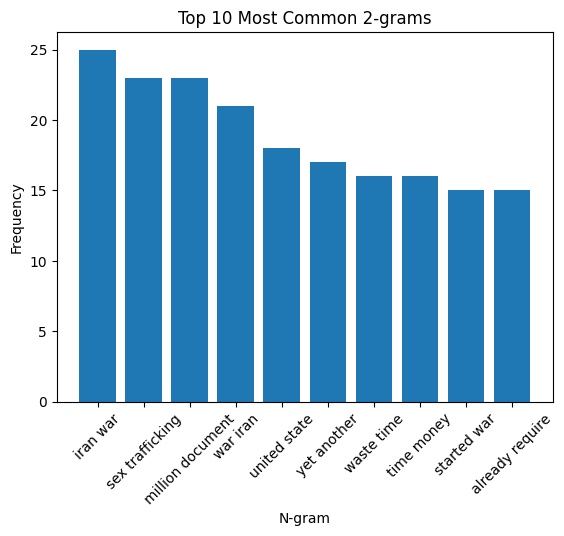

In [ ]:
from nltk import ngrams

# Distribusi Frekuensi N-gram
n = 2

ngram_counts = df['text_clean'].apply(lambda x: list(ngrams(x, n)))
ngram_counts = [ngram for ngrams_list in ngram_counts for ngram in ngrams_list]

ngram_freq = Counter(ngram_counts)

labels, values = zip(*ngram_freq.most_common(10))
labels = [' '.join(label) for label in labels]

plt.bar(labels, values)
plt.xlabel('N-gram')
plt.ylabel('Frequency')
plt.title(f'Top 10 Most Common {n}-grams')
plt.xticks(rotation=45)
plt.savefig('top_10_words_2grams.png')
plt.show()


## Top 3 - Grams

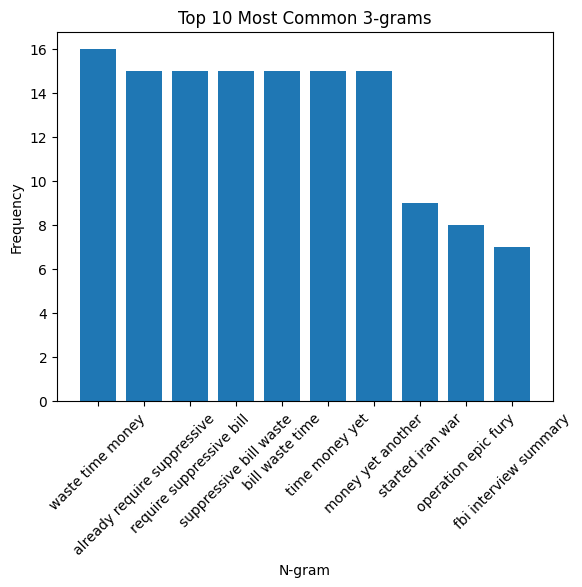

In [ ]:
# Distribusi Frekuensi N-gram
n = 3

ngram_counts = df['text_clean'].apply(lambda x: list(ngrams(x, n)))
ngram_counts = [ngram for ngrams_list in ngram_counts for ngram in ngrams_list]

ngram_freq = Counter(ngram_counts)

labels, values = zip(*ngram_freq.most_common(10))
labels = [' '.join(label) for label in labels]

plt.bar(labels, values)
plt.xlabel('N-gram')
plt.ylabel('Frequency')
plt.title(f'Top 10 Most Common {n}-grams')
plt.xticks(rotation=45)
plt.savefig('top_10_words_3grams.png')
plt.show()


---
# 6. Word Cloud
Visual representation of word frequency — larger words appear more often. Broken down by overall, positive, and negative sentiment.

## Wordcloud

## Overall

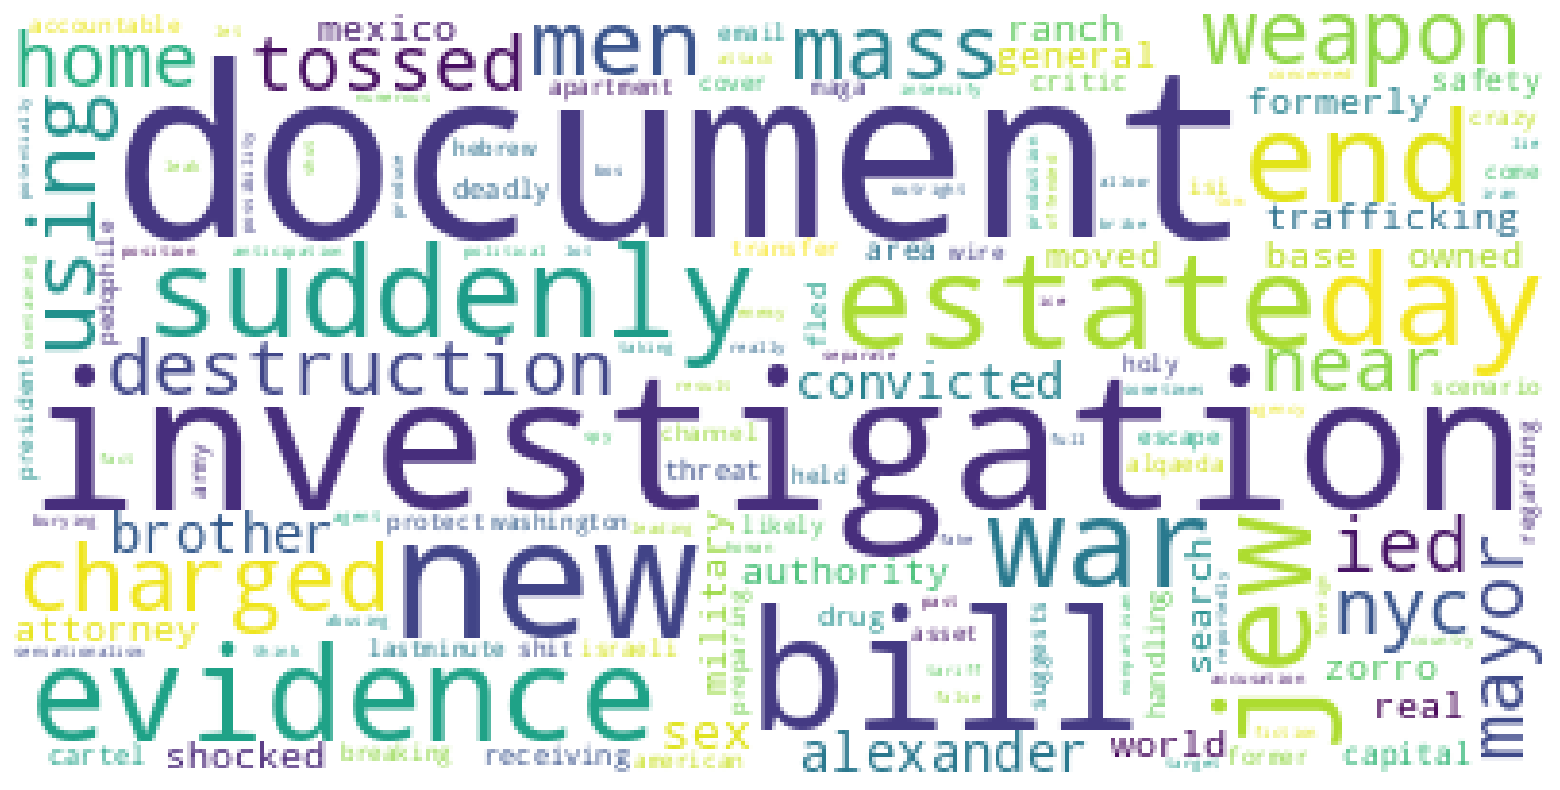

In [ ]:
def plot_cloud(wordcloud, cat):
    plt.figure(figsize=(20,10))
    plt.imshow(wordcloud)
    plt.axis('off')
    plt.savefig(f'world_cloud_{cat}.png')
    plt.show()

# Overall
word_cloud = WordCloud(background_color='white').generate(str(df['text_clean']))
plot_cloud(word_cloud, 'Overall')

## Positive

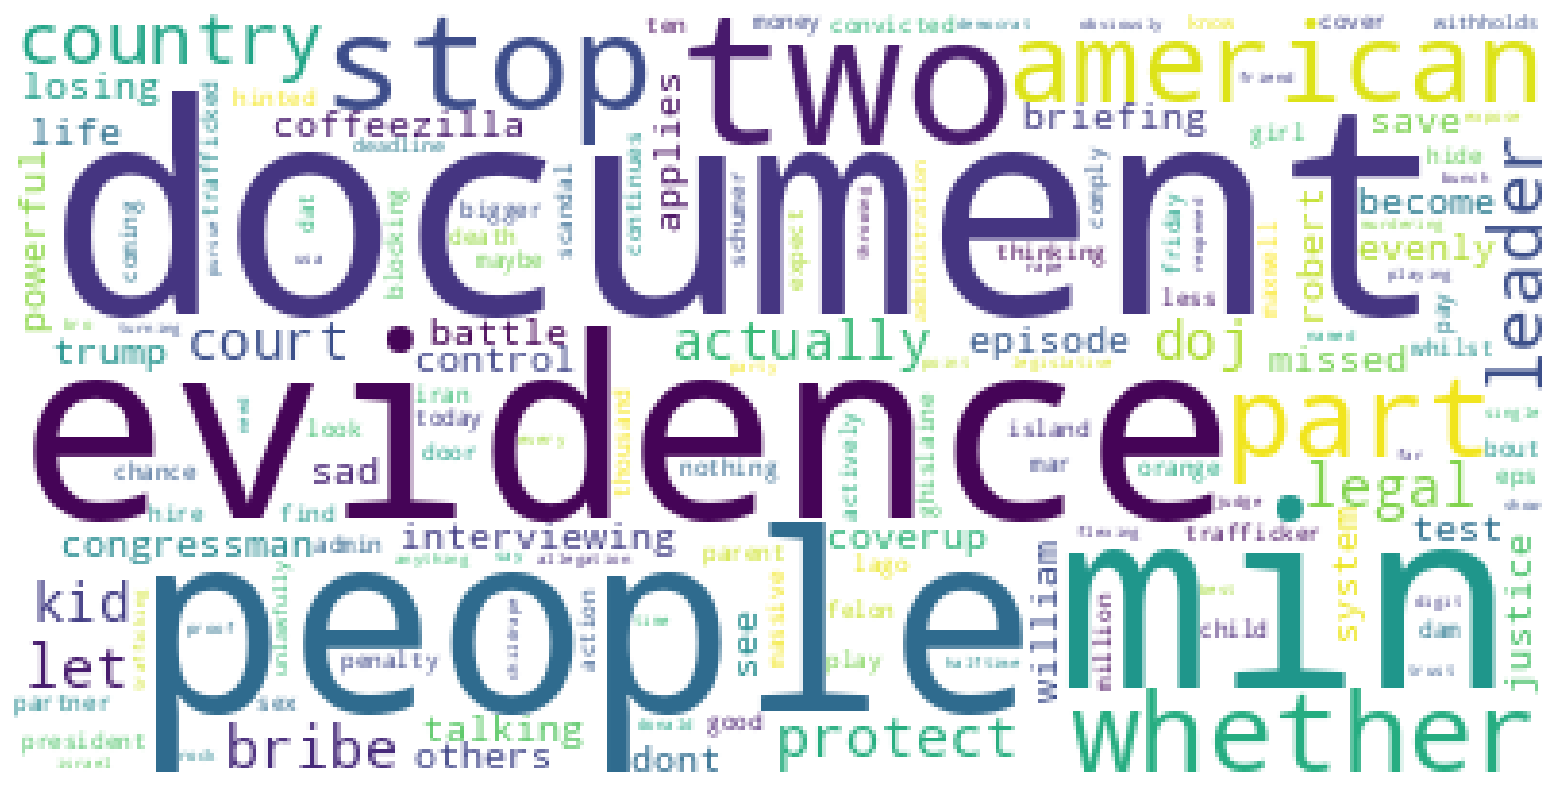

In [ ]:
word_cloud=WordCloud(background_color='white').generate(str(df[df['polarity']=='positive']['text_clean']))
plot_cloud(word_cloud, 'Positive')

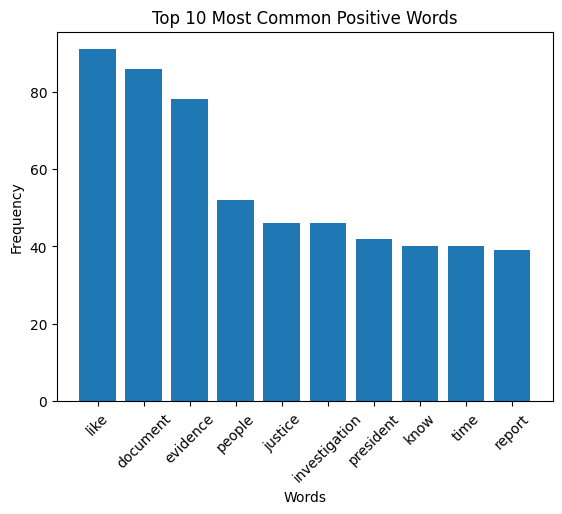


Top 10 Most Common Positive Words:
like : 91
document : 86
evidence : 78
people : 52
justice : 46
investigation : 46
president : 42
know : 40
time : 40
report : 39


In [ ]:
from collections import Counter

all_words = ' '.join(' '.join(words) for words in df[df['polarity']=='positive']['text_clean'])
word_counts = Counter(all_words.split())

top_words = word_counts.most_common(10)
labels, values = zip(*top_words)

plt.bar(labels, values)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 10 Most Common Positive Words')
plt.xticks(rotation=45)
plt.savefig('barPlot_top_10_positive_words.png')
plt.show()

print("\nTop 10 Most Common Positive Words:")
for word, count in top_words:
    print(f"{word} : {count}")

## Negative

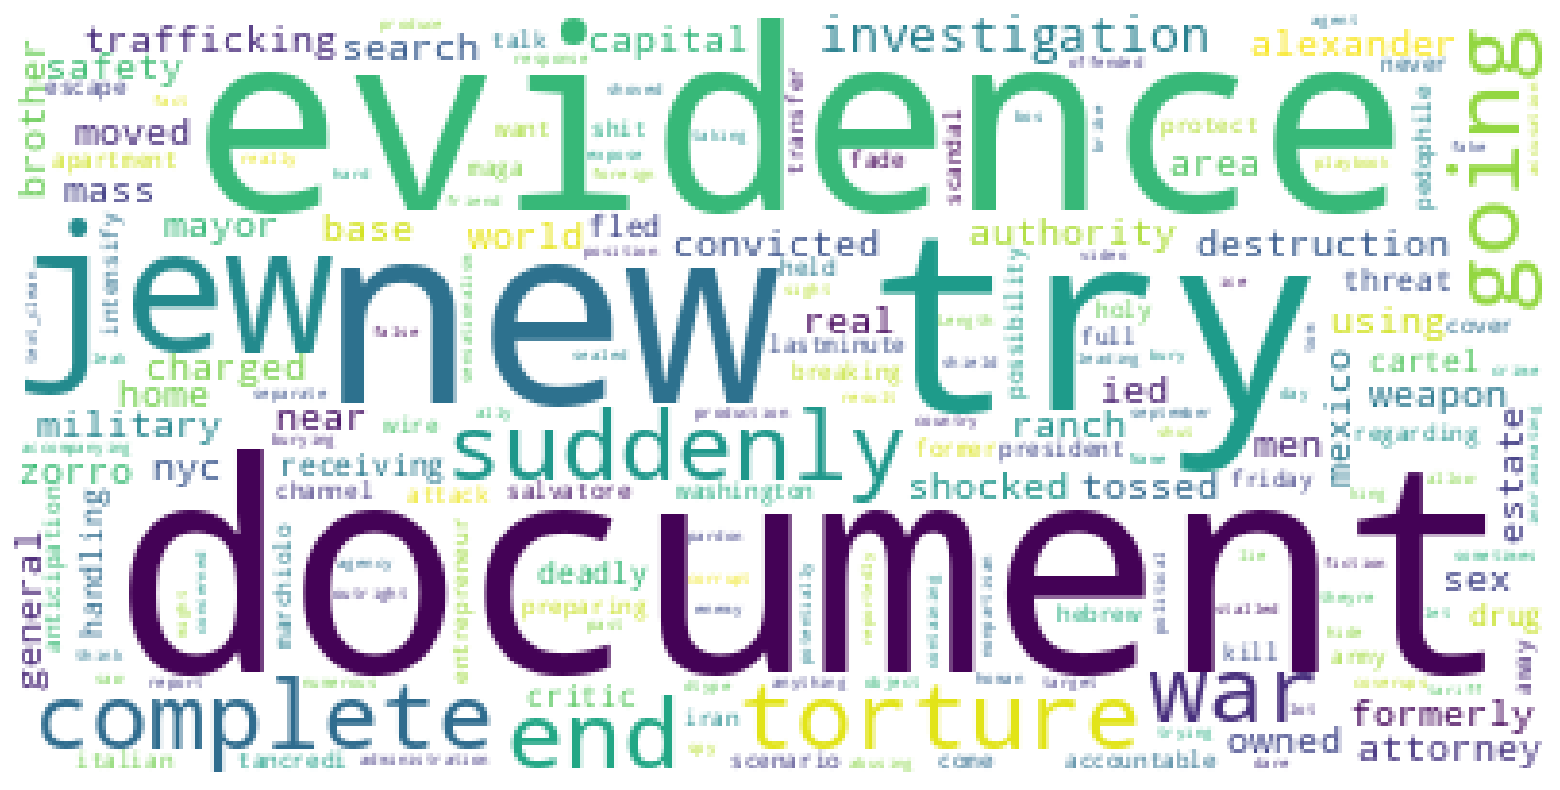

In [ ]:
word_cloud=WordCloud(background_color='white').generate(str(df[df['polarity']=='negative']['text_clean']))
plot_cloud(word_cloud, 'Negative')

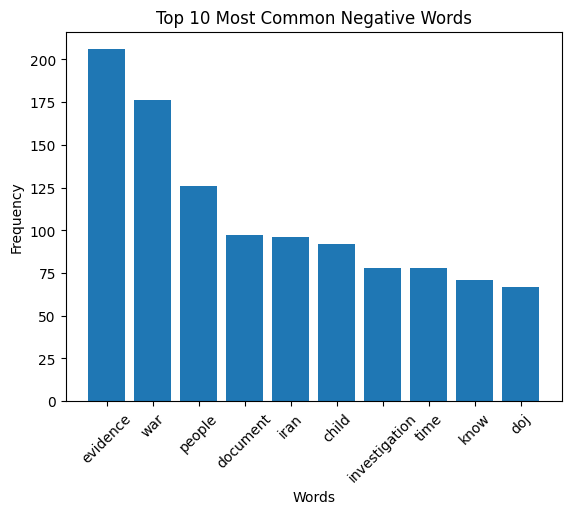


Top 10 Most Common Negative Words:
evidence : 206
war : 176
people : 126
document : 97
iran : 96
child : 92
investigation : 78
time : 78
know : 71
doj : 67


In [ ]:
from collections import Counter

all_words = ' '.join(' '.join(words) for words in df[df['polarity']=='negative']['text_clean'])
word_counts = Counter(all_words.split())

top_words = word_counts.most_common(10)
labels, values = zip(*top_words)

plt.bar(labels, values)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 10 Most Common Negative Words')
plt.xticks(rotation=45)
plt.savefig('barPlot_top_10_negative_words.png')
plt.show()

print("\nTop 10 Most Common Negative Words:")
for word, count in top_words:
    print(f"{word} : {count}")

## Length of Sentence

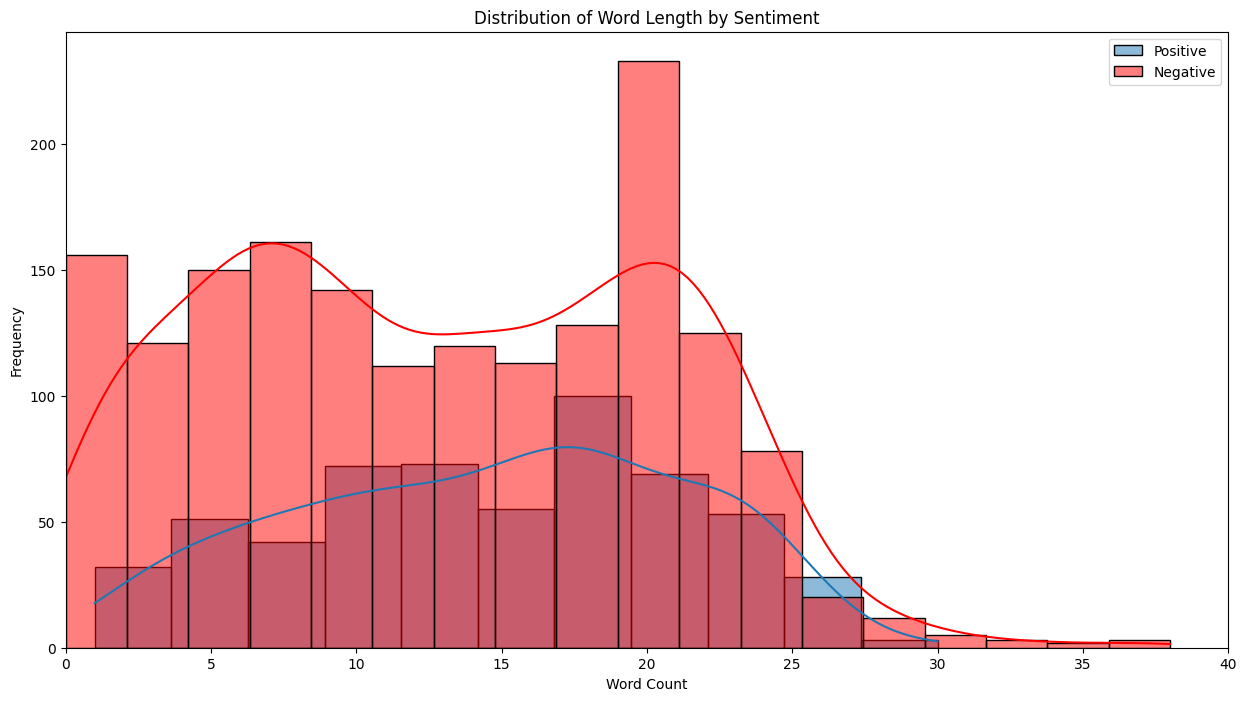

In [ ]:
df['character_length'] = df['full_text'].apply(len)  # banyak karakter
df['word_length'] = df['text_clean'].apply(len)       # banyak kata

df_pos = df[df['polarity'] == 'positive']
df_neg = df[df['polarity'] != 'positive']

plt.figure(figsize=(15,8))
sns.histplot(df_pos['word_length'], label='Positive', kde=True)
sns.histplot(df_neg['word_length'], label='Negative', kde=True, color='red')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.title('Distribution of Word Length by Sentiment')
plt.xlim(0, 40)
plt.legend()
plt.savefig('word_length_distribution.png')
plt.show()

---
# 7. Export & Data Preparation
Export processed data for visualization in **Looker Studio** and archive results.

In [ ]:
import shutil
from google.colab import files

# Define the directory to be zipped
directory_to_zip = '/content/tweets-data'
output_filename = 'sentiment_epstein_archive'

print(f"Compressing '{directory_to_zip}' into '{output_filename}.zip'...")

# Create a zip archive of the directory
shutil.make_archive(output_filename, 'zip', directory_to_zip)

print(f"'{output_filename}.zip' created. Initiating download...")

# Download the zip file
files.download(f'{output_filename}.zip')

print("Download complete!")

Compressing '/content/tweets-data' into 'sentiment_epstein_archive.zip'...
'sentiment_epstein_archive.zip' created. Initiating download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download complete!


In [ ]:
df

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username,text_clean,polarity_score,polarity,character_length,word_length
0,2031509643273396393,2026-03-10 23:21:45+00:00,0,2 men are charged with using a weapon of mass destruction after IEDs are tossed near NYC mayor s home Alexander brothers are convicted of sex trafficking in case that shocked real estate world New Mexico authorities search Zorro Ranch formerly owned by Epstein,2031510852881264963,None,V_News8,en,NaN,0,0,0,https://x.com/undefined/status/2031510852881264963,1710135965795188737,NaN,"[men, charged, using, weapon, mass, destruction, ied, tossed, near, nyc, mayor, home, alexander, brother, convicted, sex, trafficking, shocked, real, estate, world, new, mexico, authority, search, zorro, ranch, formerly, owned]",-0.8271,negative,261,29
1,2032045484852830630,Thu Mar 12 10:46:11 +0000 2026,0,ATTORNEY GENERAL PAM BONDI HAS MOVED TO A MILITARY BASE IN THE CAPITAL AREA FOR SAFETY! After receiving DEADLY THREATS from DRUG CARTELS and CRITICS over her handling of the JEFFREY EPSTEIN FILES she fled her WASHINGTON D.C. apartment in a LAST-MINUTE ESCAPE. This is NOT a https://t.co/qiVi4680DH,2032045484852830630,https://pbs.twimg.com/media/HDNGmcRWAAAOYx8.jpg,None,en,NaN,0,0,0,https://x.com/undefined/status/2032045484852830630,48115695,NaN,"[attorney, general, moved, military, base, capital, area, safety, receiving, deadly, threat, drug, cartel, critic, handling, fled, washington, apartment, lastminute, escape]",-0.2500,negative,298,20
2,1985134759811358959,Sun Nov 02 23:59:43 +0000 2025,0,Breaking maga News holy shit if it comes out that former Presidents new what was in the Epstein files regarding trump wire transfers evidence of a cover up to protect a pedophile they should be held accountable,1985134759811358959,None,None,en,NaN,0,0,0,https://x.com/undefined/status/1985134759811358959,1237140836426678273,NaN,"[breaking, maga, news, holy, shit, come, former, president, new, regarding, wire, transfer, evidence, cover, protect, pedophile, held, accountable]",-0.2500,negative,211,18
3,2032045419107356723,Thu Mar 12 10:45:56 +0000 2026,0,CRAZY: 🇺🇸🇮🇱 An email in the Epstein Files suggests ISIS and Al-Qaeda are likely American and Israeli assets. #Iran #IranWar #IranIsraelWar https://t.co/hqPD9NzjmE,2032045419107356723,https://pbs.twimg.com/media/HDNGh6pbQAEBdLL.jpg,None,en,NaN,0,0,0,https://x.com/undefined/status/2032045419107356723,2028755439366946816,NaN,"[crazy, 🇺🇸🇮🇱, email, suggests, isi, alqaeda, likely, american, israeli, asset]",0.0258,neutral,163,10
4,2031492795588825290,2026-03-10 22:10:00+00:00,0,Channel 12 (Hebrew) The Jews are preparing for a scenario in which Trump suddenly ends the war. Therefore the Jews army will intensify its attacks on Iran. In anticipation of the possibility that Trump will suddenly end the war. The full Epstein file will be released. https://t.co/MyVOzYwHNL,2031492795588825290,https://pbs.twimg.com/media/HDFP7TRXcAAjqeE.jpg,None,en,NaN,0,0,0,https://x.com/undefined/status/2031492795588825290,102819678,NaN,"[channel, hebrew, jew, preparing, scenario, suddenly, end, war, therefore, jew, army, intensify, attack, iran, anticipation, possibility, suddenly, end, war, full]",-0.8885,negative,293,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2257,2003612982161371186,Tue Dec 23 23:45:34 +0000 2025,3613,There has been lots of sensationalism and even outright lies these past few days about the Epstein Files. But let s separate fact from fiction. Document production is just that. We produce documents and sometimes this can result in releasing fake or false documents because,2003612982161371186,None,None,en,NaN,195,2673,964,https://x.com/undefined/status/2003612982161371186,1910742306820378624,NaN,"[lot, sensationalism, outright, lie, past, day, let, separate, fact, fiction, document, productio

In [ ]:
# ===================== PREPARE DATA FOR LOOKER STUDIO =====================

# Kolom yang dibutuhkan
df_looker = df[[
    'full_text',          # teks asli tweet
    'created_at',         # tanggal tweet (untuk time series)
    'text_clean',         # teks setelah preprocessing
    'polarity_score',     # skor VADER (-1 sampai 1)
    'polarity',           # label: positive/negative/neutral
    'character_length',   # panjang karakter
    'word_length',        # jumlah kata
]].copy()

# Konversi text_clean dari list ke string (BigQuery tidak bisa simpan list)
df_looker['text_clean'] = df_looker['text_clean'].apply(lambda x: ' '.join(x))

# Konversi created_at ke datetime
df_looker['created_at'] = pd.to_datetime(df_looker['created_at'], format='mixed')

# Tambah kolom tambahan yang berguna di Looker Studio
df_looker['date'] = df_looker['created_at'].dt.date        # tanggal saja
df_looker['hour'] = df_looker['created_at'].dt.hour        # jam posting
df_looker['day_of_week'] = df_looker['created_at'].dt.day_name()  # hari

# ===================== UPLOAD KE BIGQUERY =====================
project_id = 'porto-489909'
dataset_id = 'porto_sentimen'
table_name = 'data_clean_full'

credentials = service_account.Credentials.from_service_account_file(
    'porto-489909-d1e56881ea6b.json',
    scopes=["https://www.googleapis.com/auth/bigquery"]
)

pandas_gbq.to_gbq(
    df_looker,
    f'{dataset_id}.{table_name}',
    project_id=project_id,
    if_exists='replace',
    credentials=credentials
)

print(f"✅ Berhasil upload {len(df_looker)} baris ke BigQuery: {dataset_id}.{table_name}")
print(f"\nKolom yang diupload:")
print(df_looker.dtypes)

100%|██████████| 1/1 [00:00<00:00, 6647.07it/s]

✅ Berhasil upload 2262 baris ke BigQuery: porto_sentimen.data_clean_full

Kolom yang diupload:
full_text                        object
created_at          datetime64[ns, UTC]
text_clean                       object
polarity_score                  float64
polarity                         object
character_length                  int64
word_length                       int64
date                             object
hour                              int32
day_of_week                      object
dtype: object


---
# 8. Conclusions & Recommendations

## Key Findings
| # | Finding |
|---|--------|
| 1 | **Negative sentiment dominates at ~49.6%** — public discourse is emotionally charged and adversarial |
| 2 | **Positive (25.6%) and Neutral (24.9%) are roughly equal** — a portion of users shared information without strong emotional tone |
| 3 | **Overall pattern reflects moral outrage and systemic critique** rather than neutral deliberation |

## Recommendations for the Editorial Team

**1. Improve Transparency in Institutional Reporting**
- Keywords like `doj`, `evidence`, and `document` dominate → the public wants clarity on legal processes.
- Cover investigation updates consistently and help audiences understand released legal documents.

**2. Maintain a Victim-Centered Perspective**
- The word `child` frequently appears in the data → public concern for victims is significant.
- Focus coverage on victims and legal proceedings related to them, not just political controversy.